## Proyecto Integrador – Fase 1: Modelo Predictivo de Abandono de Clientes

**Asignatura:** Modelos y Simulación de Sistemas I

**Integrantes:** Shara Olaya Araque, Liceth Alexandra Sarmiento

## 1. Introducción

### Problema
Las empresas de telecomunicaciones pierden ingresos cuando sus clientes
cancelan el servicio. Identificar con anticipación qué clientes tienen mayor
probabilidad de abandonar permite a la empresa tomar acciones de retención
(ofertas, mejoras en el servicio, contacto personalizado) antes de que el
abandono ocurra.

### Objetivo
Construir un modelo de Machine Learning que, a partir de las características
de un cliente (servicios contratados, tipo de contrato, cargos, antigüedad,
entre otras), prediga si el cliente abandonará el servicio.

### Tipo de problema
Clasificación binaria supervisada: el modelo aprende a partir de ejemplos
etiquetados y debe asignar a cada cliente una de dos clases.

### Variable objetivo
`Churn`: indica si el cliente abandonó el servicio (`Yes`) o permaneció (`No`).

### Fuente de datos
Dataset *Telco Customer Churn*, disponible en Kaggle:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Configuración del entorno**

En esta sección se importan las librerías base del proyecto y se registran sus versiones, con el fin de garantizar la reproducibilidad. Además, se define la constante RANDOM_STATE = 42, que se utilizará en todos los procesos que involucren aleatoriedad (división de datos, entrenamiento de modelos), de modo que los resultados sean los mismos en cada ejecución.

In [31]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                                f1_score, roc_auc_score, confusion_matrix,
                                classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

# Semilla aleatoria fija para todo el proyecto
RANDOM_STATE = 42

print("Versión de Python:", sys.version)
print("Versión de numpy:", np.__version__)
print("Versión de pandas:", pd.__version__)
print("Versión de matplotlib:", matplotlib.__version__)
print("Versión de scikit-learn:", sklearn.__version__)
print("Versión de joblib:", joblib.__version__)

Versión de Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Versión de numpy: 2.1.3
Versión de pandas: 2.2.3
Versión de matplotlib: 3.10.0
Versión de scikit-learn: 1.6.1
Versión de joblib: 1.6.0


**Carga del dataset;** El archivo CSV se encuentra almacenado en el repositorio del proyecto y se carga directamente desde GitHub, de modo que el notebook pueda ejecutarse sin descargas ni cargas manuales de archivos.

In [32]:
# Carga del dataset
# URL "raw" del CSV guardado en el repositorio de GitHub
URL_DATASET = "https://raw.githubusercontent.com/Alexa0723/Proyecto_Modelos1/refs/heads/main/fase-1/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Leer el CSV y convertirlo en un DataFrame
datos_clientes = pd.read_csv(URL_DATASET)

# Dimensiones del dataset
numero_de_registros = datos_clientes.shape[0]
numero_de_variables = datos_clientes.shape[1]

print("Número de registros (filas):", numero_de_registros)
print("Número de variables (columnas):", numero_de_variables)

Número de registros (filas): 7043
Número de variables (columnas): 21


In [33]:
# Mostrar las primeras 5 filas del dataset
datos_clientes.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [34]:
# Mostrar la lista completa de nombres de columnas
print(datos_clientes.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 2. Descripción del dataset

El dataset contiene 7043 registros,donde cada registro corresponde a un
cliente, y 21 variables, que pueden agruparse así:

- **Identificador:** customerID, código único de cada cliente.
- **Datos demográficos:** gender, SeniorCitizen, Partner, `Dependents`.
- **Servicios contratados:** `PhoneService`, `MultipleLines`, `InternetService`,
  `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,
  `StreamingTV`, `StreamingMovies`.
- **Cuenta y facturación:** `tenure` (meses como cliente), `Contract`,
  `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`.
- **Variable objetivo:** `Churn`, que indica si el cliente abandonó el
  servicio (`Yes`) o permaneció (`No`).

Observaciones iniciales:
- `customerID` es un identificador, por lo que no aporta información
  predictiva; su exclusión se justifica más adelante.
- `SeniorCitizen` está codificada como 0/1, aunque representa una variable
  categórica (si el cliente es adulto mayor o no).
- Algunas variables de servicios contienen categorías como
  "No phone service", que no corresponden a valores faltantes sino a
  clientes que no tienen el servicio base.

**Limitaciones del dataset:**
- Los datos corresponden a un único momento en el tiempo; no incluyen fechas,
  por lo que no es posible saber cuándo abandonó cada cliente ni analizar la
  evolución de su comportamiento.
- La variable objetivo está desbalanceada (26,54 % de abandono), lo que
  condiciona la elección de métricas.
- `TotalCharges` presenta 11 valores faltantes, correspondientes a clientes
  nuevos.

## 3. Exploración de datos

### 3.1 Tipos de datos
Se revisa el tipo de dato con el que pandas almacenó cada variable, para
verificar que coincida con lo que la variable representa.

In [35]:
# 3.1 Tipos de datos
# Resumen de columnas: tipo de dato y cantidad de valores no nulos
datos_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


El dataset contiene 18 variables de tipo texto (object), 2 de tipo entero
(int64) y 1 de tipo decimal (float64). Según `.info()`, todas las columnas
tienen 7043 valores no nulos.

Se identifican dos situaciones que requieren atención:

- `TotalCharges` fue almacenada como texto (object), aunque representa un
  valor monetario. Esto indica que la columna contiene al menos un valor que
  pandas no pudo interpretar como número, por lo que se analiza en la
  sección 3.3.
- `SeniorCitizen` es de tipo int64, pero representa una variable categórica
  binaria (0 = no es adulto mayor, 1 = sí lo es), por lo que no debe
  tratarse como una cantidad.

### 3.2 Verificación del identificador
Se comprueba si `customerID` identifica de forma única a cada cliente.

In [36]:
# 3.2 Verificación del identificador customerID

cantidad_ids_unicos = datos_clientes["customerID"].nunique()
cantidad_total_registros = len(datos_clientes)

print("Valores únicos en customerID:", cantidad_ids_unicos)
print("Total de registros:", cantidad_total_registros)

if cantidad_ids_unicos == cantidad_total_registros:
    print("Cada cliente tiene un customerID distinto: la columna es un identificador único.")
else:
    print("Hay valores de customerID repetidos: es necesario revisarlos.")

Valores únicos en customerID: 7043
Total de registros: 7043
Cada cliente tiene un customerID distinto: la columna es un identificador único.


`customerID` tiene 7043 valores únicos para 7043 registros. Esto confirma
que cada cliente aparece una sola vez (no hay registros duplicados) y que la
columna funciona como identificador. Como no describe ninguna característica
del cliente, no se utilizará como variable predictora: si el modelo la usara,
podría memorizar clientes específicos en lugar de aprender patrones
generalizables.

### 3.3 Valores faltantes
Se cuantifican los valores faltantes en dos pasos: primero los valores nulos
(NaN) que pandas detecta directamente, y luego los textos vacíos, que pandas
no reconoce como faltantes.

In [37]:
# 3.3 Valores faltantes (NaN)

faltantes_por_columna = datos_clientes.isnull().sum()

print("Valores faltantes (NaN) por columna:")
print(faltantes_por_columna)
print()
print("Total de valores faltantes (NaN) en el dataset:", faltantes_por_columna.sum())

Valores faltantes (NaN) por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total de valores faltantes (NaN) en el dataset: 0


La función `isnull()` no detecta valores nulos (NaN) en ninguna columna.
Sin embargo, esto no garantiza la ausencia de datos faltantes: un texto vacío
o compuesto solo por espacios no es reconocido por pandas como valor nulo.
Por esta razón, se realiza una búsqueda adicional en las columnas de texto.

In [38]:
# 3.4 Búsqueda de valores vacíos escondidos en columnas de texto

columnas_de_texto = datos_clientes.select_dtypes(include="object").columns
se_encontraron_vacios = False

for nombre_columna in columnas_de_texto:
    cantidad_vacios = (datos_clientes[nombre_columna].str.strip() == "").sum()

    if cantidad_vacios > 0:
        print("Columna", nombre_columna, "tiene", cantidad_vacios, "valores vacíos")
        se_encontraron_vacios = True

if se_encontraron_vacios == False:
    print("No se encontraron valores vacíos escondidos en las columnas de texto.")

Columna TotalCharges tiene 11 valores vacíos


Se encontraron 11 valores vacíos en la columna TotalCharges. Estos valores
explican por qué pandas almacenó la columna como texto. Ninguna otra columna
de texto presenta valores vacíos.

In [39]:
# 3.5 Conversión de TotalCharges a tipo numérico

print("Tipo de TotalCharges antes de la conversión:", datos_clientes["TotalCharges"].dtype)

datos_clientes["TotalCharges"] = pd.to_numeric(datos_clientes["TotalCharges"], errors="coerce")

print("Tipo de TotalCharges después de la conversión:", datos_clientes["TotalCharges"].dtype)
print("Valores faltantes (NaN) en TotalCharges después de la conversión:",
      datos_clientes["TotalCharges"].isnull().sum())

Tipo de TotalCharges antes de la conversión: object
Tipo de TotalCharges después de la conversión: float64
Valores faltantes (NaN) en TotalCharges después de la conversión: 11


`TotalCharges` se convirtió de texto (object) a número decimal (float64)
mediante `pd.to_numeric` con `errors="coerce"`, que transforma los valores no
convertibles en NaN. Después de la conversión, la columna tiene exactamente
11 valores NaN, lo que coincide con los 11 vacíos encontrados. Esto confirma
que no existían otros valores no numéricos en la columna.

Esta conversión no genera fuga de información, ya que se aplica de forma
independiente a cada fila y no utiliza información de otros registros.

In [40]:
# 3.6 Análisis de las filas con TotalCharges faltante

filas_sin_total_charges = datos_clientes[datos_clientes["TotalCharges"].isnull()]

cantidad_filas_sin_total = len(filas_sin_total_charges)
porcentaje_filas_sin_total = cantidad_filas_sin_total / len(datos_clientes) * 100

print("Filas con TotalCharges faltante:", cantidad_filas_sin_total)
print("Porcentaje del total de registros:", round(porcentaje_filas_sin_total, 2), "%")

filas_sin_total_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

Filas con TotalCharges faltante: 11
Porcentaje del total de registros: 0.16 %


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,NaN,Two year,No
753,3115-CZMZD,0,20.25,NaN,Two year,No
936,5709-LVOEQ,0,80.85,NaN,Two year,No
1082,4367-NUYAO,0,25.75,NaN,Two year,No
1340,1371-DWPAZ,0,56.05,NaN,Two year,No
3331,7644-OMVMY,0,19.85,NaN,Two year,No
3826,3213-VVOLG,0,25.35,NaN,Two year,No
4380,2520-SGTTA,0,20.00,NaN,Two year,No
5218,2923-ARZLG,0,19.70,NaN,One year,No
6670,4075-WKNIU,0,73.35,NaN,Two year,No


In [41]:
# 3.7 ¿Los faltantes corresponden a clientes con tenure = 0?

cantidad_clientes_tenure_cero = (datos_clientes["tenure"] == 0).sum()
print("Clientes con tenure = 0:", cantidad_clientes_tenure_cero)

faltantes_con_tenure_cero = (filas_sin_total_charges["tenure"] == 0).sum()
print("Filas con TotalCharges faltante que tienen tenure = 0:", faltantes_con_tenure_cero)

if faltantes_con_tenure_cero == cantidad_filas_sin_total:
    print("Todas las filas con TotalCharges faltante son clientes con tenure = 0.")
else:
    print("No todas las filas con TotalCharges faltante tienen tenure = 0: hay que revisar.")

Clientes con tenure = 0: 11
Filas con TotalCharges faltante que tienen tenure = 0: 11
Todas las filas con TotalCharges faltante son clientes con tenure = 0.


Los 11 registros con `TotalCharges` faltante representan el 0,16 % del
dataset. Al analizarlos se observa que:

- Todos tienen `tenure = 0`, es decir, son clientes que acaban de ingresar a
  la empresa. Además, son los únicos 11 clientes del dataset con `tenure = 0`.
- Todos tienen un valor en `MonthlyCharges`, es decir, ya tienen una tarifa
  asignada.
- Todos tienen `Churn = No`.
- 10 tienen contrato `Two year` y 1 tiene contrato `One year`.

Por lo tanto, los valores faltantes no son aleatorios ni corresponden a
errores de captura: se trata de clientes nuevos a los que todavía no se les ha
realizado ningún cobro, por lo que su cargo total acumulado aún no existe.

El tratamiento de estos valores se decide en la sección 4. Cualquier
imputación se ajustará únicamente con los datos de entrenamiento, para evitar
fuga de información.

### 3.4 Estadísticas descriptivas

In [42]:
# 3.8 Estadísticas descriptivas: variables numéricas

datos_clientes.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Observaciones sobre las variables numéricas:

- **SeniorCitizen:** al ser una variable binaria (0/1), su media corresponde a
  la proporción de clientes adultos mayores: 16,2 %.
- **tenure:** varía entre 0 y 72 meses, con media de 32,37 y mediana de 29
  meses.
- **MonthlyCharges:** varía entre 18,25 y 118,75, con media de 64,76 y mediana
  de 70,35. La mediana es mayor que la media, lo que indica un grupo de
  clientes con cargos mensuales bajos.
- **TotalCharges:** tiene 7032 valores (7043 menos los 11 faltantes). Varía
  entre 18,80 y 8684,80, con media de 2283,30 y mediana de 1397,48. La media
  es considerablemente mayor que la mediana, lo que indica una distribución
  sesgada a la derecha: pocos clientes con cargos acumulados muy altos.

No se observan valores negativos ni fuera de rangos razonables. Las variables
numéricas se encuentran en escalas muy diferentes (por ejemplo, `tenure`
llega hasta 72, mientras que `TotalCharges` llega hasta 8684,80), lo cual
se considerará en la preparación de los datos.

In [43]:
# 3.9 Estadísticas descriptivas: variables categóricas

datos_clientes.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


Observaciones sobre las variables categóricas:

- La mayoría de variables tiene 2 o 3 categorías; `PaymentMethod` tiene 4.
- `gender` está prácticamente balanceada (Male: 3555 clientes, 50,48 %).
- El 90,32 % de los clientes tiene servicio telefónico (`PhoneService = Yes`).
- El tipo de contrato más frecuente es `Month-to-month` (3875 clientes,
  55,02 %).
- El método de pago más frecuente es `Electronic check` (2365 clientes,
  33,58 %).
- **Variable objetivo:** 5174 clientes (73,46 %) tienen `Churn = No`, por lo
  que 1869 clientes (26,54 %) abandonaron el servicio. Las clases están
  desbalanceadas; esto se analiza en la sección 3.5 y se tiene en cuenta en
  la elección de las métricas de evaluación.

In [44]:
# 3.10 Categorías de cada variable categórica

columnas_categoricas = datos_clientes.select_dtypes(include="object").columns

for nombre_columna in columnas_categoricas:
    if nombre_columna == "customerID":
        continue
    else:
        categorias = datos_clientes[nombre_columna].unique()
        print(nombre_columna, ":", list(categorias))

gender : ['Female', 'Male']
Partner : ['Yes', 'No']
Dependents : ['No', 'Yes']
PhoneService : ['No', 'Yes']
MultipleLines : ['No phone service', 'No', 'Yes']
InternetService : ['DSL', 'Fiber optic', 'No']
OnlineSecurity : ['No', 'Yes', 'No internet service']
OnlineBackup : ['Yes', 'No', 'No internet service']
DeviceProtection : ['No', 'Yes', 'No internet service']
TechSupport : ['No', 'Yes', 'No internet service']
StreamingTV : ['No', 'Yes', 'No internet service']
StreamingMovies : ['No', 'Yes', 'No internet service']
Contract : ['Month-to-month', 'One year', 'Two year']
PaperlessBilling : ['Yes', 'No']
PaymentMethod : ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Churn : ['No', 'Yes']


Las categorías de cada variable no presentan errores de escritura ni valores
inesperados. `Churn` tiene exactamente dos valores (`Yes` y `No`).

Se identifican categorías que dependen de otra variable:

- `"No phone service"` en `MultipleLines` corresponde a clientes con
  `PhoneService = No`.
- `"No internet service"` aparece en `OnlineSecurity`, `OnlineBackup`,
  `DeviceProtection`, `TechSupport`, `StreamingTV` y `StreamingMovies`, y
  corresponde a clientes con `InternetService = No`.

Estas categorías no son valores faltantes: indican que el cliente no tiene el
servicio base. Sin embargo, repiten información ya contenida en
`PhoneService` e `InternetService`. Esta redundancia se analiza en la
sección 4.

**Clasificación de las variables según lo que representan:**
- Identificador (no se usará como predictor): `customerID`.
- Variable objetivo: `Churn`.
- Numéricas (3): `tenure`, `MonthlyCharges`, `TotalCharges`.
- Categóricas (16): `gender`, `SeniorCitizen`, `Partner`, `Dependents`,
  `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`,
  `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`,
  `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`.

### 3.5 Distribución de la variable objetivo

Se analiza la proporción de clientes que abandonaron y que permanecieron, ya
que un desbalance entre las clases condiciona la elección de las métricas de
evaluación y la interpretación del modelo base.

Cantidad de clientes por clase:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentaje de clientes por clase:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


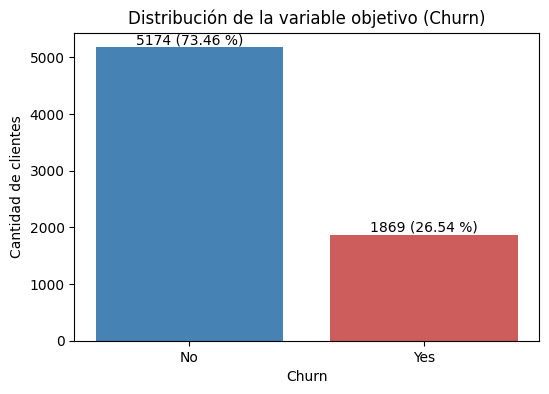

In [45]:
# 3.5 Distribución de la variable objetivo (Churn)

conteo_churn = datos_clientes["Churn"].value_counts()
porcentaje_churn = datos_clientes["Churn"].value_counts(normalize=True) * 100

print("Cantidad de clientes por clase:")
print(conteo_churn)
print()
print("Porcentaje de clientes por clase:")
print(porcentaje_churn.round(2))

# Gráfico de barras
categorias_churn = conteo_churn.index.tolist()
cantidades_churn = conteo_churn.values.tolist()

figura, eje = plt.subplots(figsize=(6, 4))
eje.bar(categorias_churn, cantidades_churn, color=["steelblue", "indianred"])

for indice in range(len(categorias_churn)):
    porcentaje_redondeado = round(porcentaje_churn.iloc[indice], 2)
    texto_barra = str(cantidades_churn[indice]) + " (" + str(porcentaje_redondeado) + " %)"
    eje.text(indice, cantidades_churn[indice], texto_barra, ha="center", va="bottom")

eje.set_title("Distribución de la variable objetivo (Churn)")
eje.set_xlabel("Churn")
eje.set_ylabel("Cantidad de clientes")
plt.show()

De los 7043 clientes, 5174 (73,46 %) permanecieron en la empresa y 1869
(26,54 %) abandonaron el servicio. Estos valores coinciden con los obtenidos
en la sección 3.4.

Las clases están desbalanceadas: por cada cliente que abandona, hay
aproximadamente tres que permanecen. Esto tiene dos implicaciones:

- Un modelo que prediga siempre "No" obtendría un accuracy cercano al 73 %
  sin aprender ningún patrón. Por eso es necesario comparar el modelo
  predictivo con un modelo base.
- El accuracy por sí solo no es una métrica suficiente; se deben considerar
  métricas que evalúen específicamente la capacidad de identificar a los
  clientes que abandonan.

### 3.6 Variables numéricas según Churn

Se compara la mediana de cada variable numérica entre los clientes que
abandonaron y los que permanecieron. Se utiliza la mediana en lugar de la
media porque `TotalCharges` presenta una distribución sesgada, y la mediana
no se ve afectada por los valores extremos. Los diagramas de caja permiten
comparar la distribución completa de cada grupo.

In [46]:
# 3.6 Variables numéricas según Churn

variables_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

medianas_por_churn = datos_clientes.groupby("Churn")[variables_numericas].median()

print("Mediana de cada variable numérica según Churn:")
print(medianas_por_churn.round(2))

Mediana de cada variable numérica según Churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0           64.43       1683.60
Yes      10.0           79.65        703.55


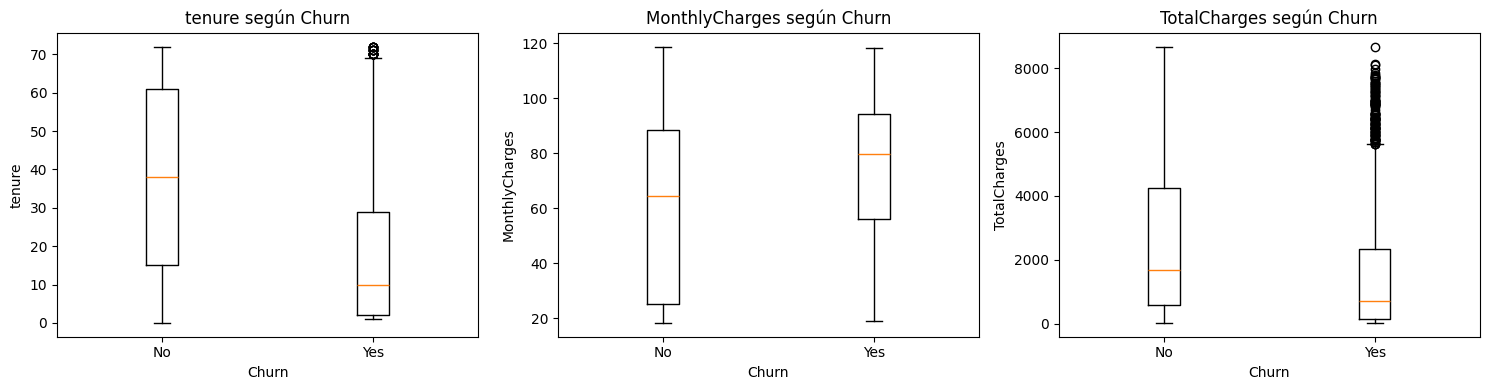

In [47]:
# Diagramas de caja: comparación de cada variable numérica entre clientes
# que permanecieron (No) y clientes que abandonaron (Yes)

figura, ejes = plt.subplots(1, 3, figsize=(15, 4))

for indice in range(len(variables_numericas)):
    nombre_variable = variables_numericas[indice]

    valores_permanecen = datos_clientes[datos_clientes["Churn"] == "No"][nombre_variable].dropna()
    valores_abandonan = datos_clientes[datos_clientes["Churn"] == "Yes"][nombre_variable].dropna()

    ejes[indice].boxplot([valores_permanecen, valores_abandonan], tick_labels=["No", "Yes"])
    ejes[indice].set_title(nombre_variable + " según Churn")
    ejes[indice].set_xlabel("Churn")
    ejes[indice].set_ylabel(nombre_variable)

plt.tight_layout()
plt.show()

Observaciones:

- **tenure:** es la variable numérica con la diferencia más clara entre
  grupos. La mediana de los clientes que abandonaron es de 10 meses, frente
  a 38 meses de los que permanecieron. En el diagrama de caja, la mayor parte
  de quienes abandonan se concentra en los primeros meses. Esto indica que
  el riesgo de abandono es mayor en clientes recientes.
- **MonthlyCharges:** los clientes que abandonaron tienen cargos mensuales
  más altos (mediana de 79,65 frente a 64,43), aunque las distribuciones de
  ambos grupos se superponen considerablemente.
- **TotalCharges:** los clientes que abandonaron tienen cargos totales más
  bajos (mediana de 703,55 frente a 1683,60). Esto no indica que pagar menos
  aumente el abandono: como `TotalCharges` es un valor acumulado, es menor en
  clientes con poca antigüedad, que son precisamente los que más abandonan.
  Esta relación se analiza en la sección 3.8.

### 3.7 Variables categóricas según Churn

Para cada variable categórica se calcula la tasa de abandono por categoría,
es decir, el porcentaje de clientes de cada categoría que abandonaron el
servicio. Se comparan tasas en lugar de cantidades porque las categorías
tienen tamaños diferentes. La tasa de abandono global se utiliza como
referencia.

**Nota sobre fuga de información:** este análisis se realiza sobre el dataset
completo con fines descriptivos, para comprender el problema. Sus resultados
no se utilizan para seleccionar ni eliminar variables; las decisiones de
preparación de datos se basan en el significado de cada variable, de modo
que el conjunto de prueba no influye en el diseño del modelo.

In [48]:
# 3.7 Variables categóricas según Churn

variables_categoricas = ["gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling",
    "PaymentMethod"]

# Serie auxiliar: True si el cliente abandonó, False si permaneció
es_abandono = datos_clientes["Churn"] == "Yes"

tasa_abandono_global = es_abandono.mean() * 100
print("Tasa de abandono global:", round(tasa_abandono_global, 2), "%")
print()

for nombre_variable in variables_categoricas:
    grupos = es_abandono.groupby(datos_clientes[nombre_variable])

    tabla_resumen = pd.DataFrame({
        "cantidad_clientes": grupos.size(),
        "tasa_abandono_%": (grupos.mean() * 100).round(2)
    })

    print("Variable:", nombre_variable)
    print(tabla_resumen)
    print()

Tasa de abandono global: 26.54 %

Variable: gender
        cantidad_clientes  tasa_abandono_%
gender                                    
Female               3488            26.92
Male                 3555            26.16

Variable: SeniorCitizen
               cantidad_clientes  tasa_abandono_%
SeniorCitizen                                    
0                           5901            23.61
1                           1142            41.68

Variable: Partner
         cantidad_clientes  tasa_abandono_%
Partner                                    
No                    3641            32.96
Yes                   3402            19.66

Variable: Dependents
            cantidad_clientes  tasa_abandono_%
Dependents                                    
No                       4933            31.28
Yes                      2110            15.45

Variable: PhoneService
              cantidad_clientes  tasa_abandono_%
PhoneService                                    
No                       

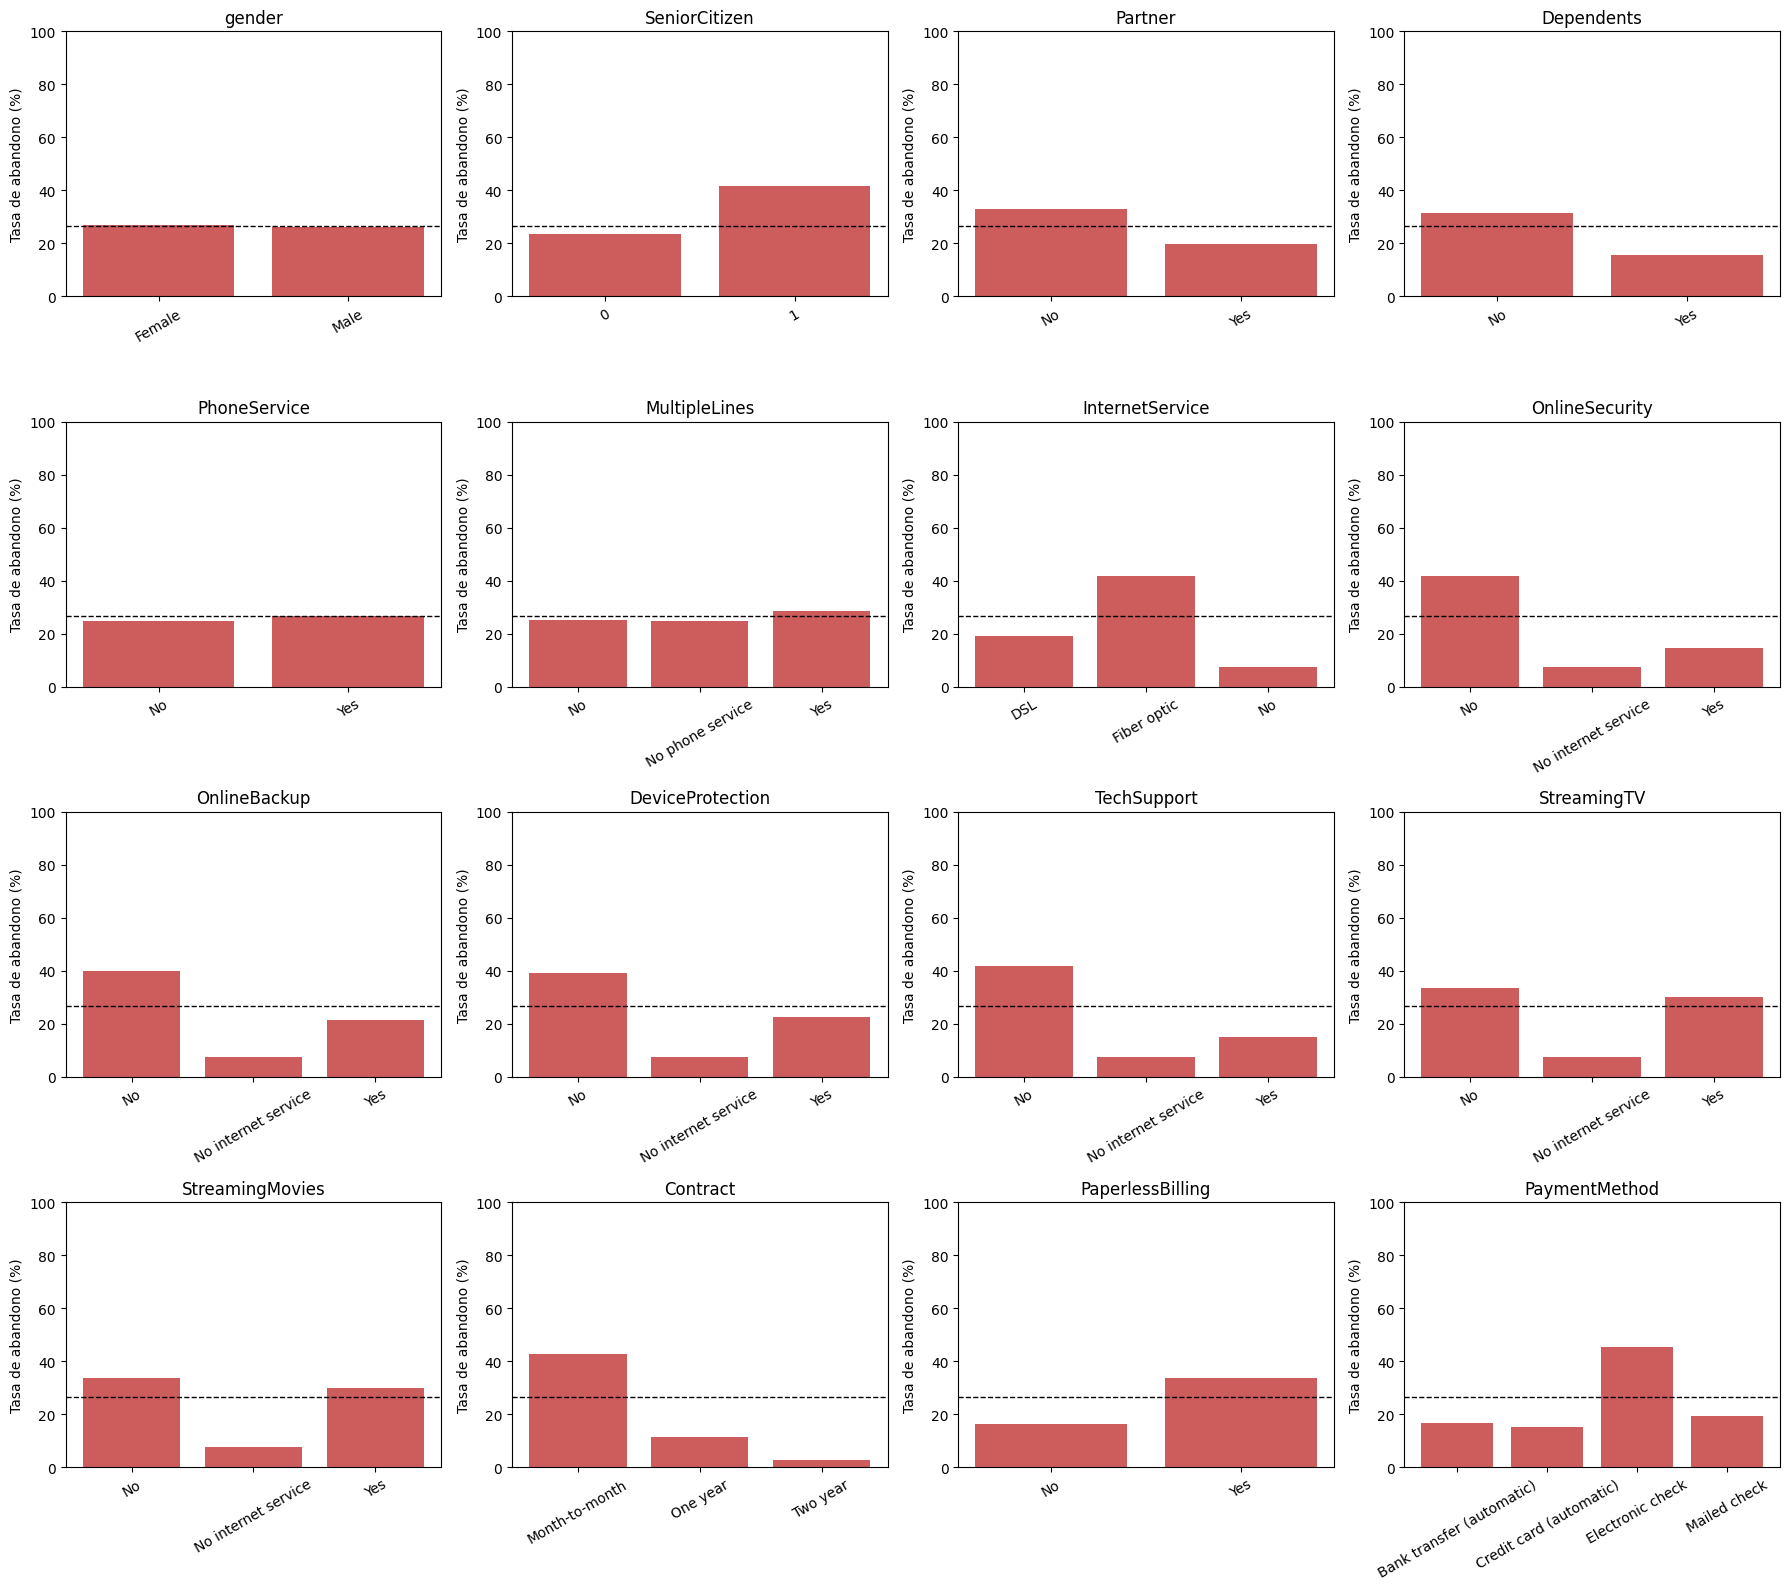

In [49]:
# Tasa de abandono por categoría para las 16 variables categóricas.
# La línea punteada negra marca la tasa de abandono global.

figura, ejes = plt.subplots(4, 4, figsize=(18, 16))
lista_de_ejes = ejes.flatten()

for indice in range(len(variables_categoricas)):
    nombre_variable = variables_categoricas[indice]
    eje = lista_de_ejes[indice]

    tasa_por_categoria = es_abandono.groupby(datos_clientes[nombre_variable]).mean() * 100

    eje.bar(tasa_por_categoria.index.astype(str), tasa_por_categoria.values, color="indianred")
    eje.axhline(tasa_abandono_global, color="black", linestyle="--", linewidth=1)
    eje.set_title(nombre_variable)
    eje.set_ylabel("Tasa de abandono (%)")
    eje.set_ylim(0, 100)
    eje.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Tomando como referencia la tasa de abandono global (26,54 %), se observa:

**Variables con relación fuerte con el abandono:**
- **Contract:** es la variable con mayor diferencia entre categorías. Los
  clientes con contrato mensual tienen una tasa de abandono de 42,71 %,
  frente a 11,27 % en contratos de un año y 2,83 % en contratos de dos años.
- **PaymentMethod:** los clientes que pagan con cheque electrónico tienen la
  tasa de abandono más alta de todas las categorías analizadas (45,29 %),
  mientras que los demás métodos se encuentran entre 15,24 % y 19,11 %.
- **InternetService:** los clientes con fibra óptica abandonan en un 41,89 %,
  frente a 18,96 % con DSL y 7,40 % sin servicio de internet.
- **Servicios de soporte** (`OnlineSecurity`, `TechSupport`, `OnlineBackup`,
  `DeviceProtection`): los clientes que no tienen estos servicios presentan
  tasas de abandono entre 39,13 % y 41,77 %, mientras que quienes sí los
  tienen presentan tasas entre 14,61 % y 22,50 %.

**Variables con relación moderada:** `SeniorCitizen` (41,68 % en adultos
mayores frente a 23,61 %), `PaperlessBilling` (33,57 % con facturación
electrónica frente a 16,33 %), `Dependents` (31,28 % sin dependientes frente
a 15,45 %) y `Partner` (32,96 % sin pareja frente a 19,66 %).

**Variables con relación débil:** `gender` (26,92 % frente a 26,16 %),
`PhoneService`, `MultipleLines`, `StreamingTV` y `StreamingMovies` presentan
tasas cercanas a la global o diferencias pequeñas entre categorías. De
acuerdo con lo establecido en la sección 3.7, estas variables no se eliminan
por este motivo.

**Redundancia confirmada:** la categoría "No internet service" tiene
exactamente 1526 clientes y una tasa de 7,40 % en las seis variables de
servicios, los mismos valores que `InternetService = No`. Esto confirma que
se trata de los mismos clientes y que esa categoría repite información ya
contenida en `InternetService`.

### 3.8 Correlación entre variables numéricas

Se calcula la correlación de Pearson entre las variables numéricas para
identificar relaciones lineales fuertes que puedan indicar información
redundante. `SeniorCitizen` no se incluye porque, aunque está codificada como
número, es una variable categórica.

In [50]:
# 3.8 Correlación entre variables numéricas

matriz_correlacion = datos_clientes[variables_numericas].corr()

print("Matriz de correlación de Pearson:")
print(matriz_correlacion.round(3))

Matriz de correlación de Pearson:
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


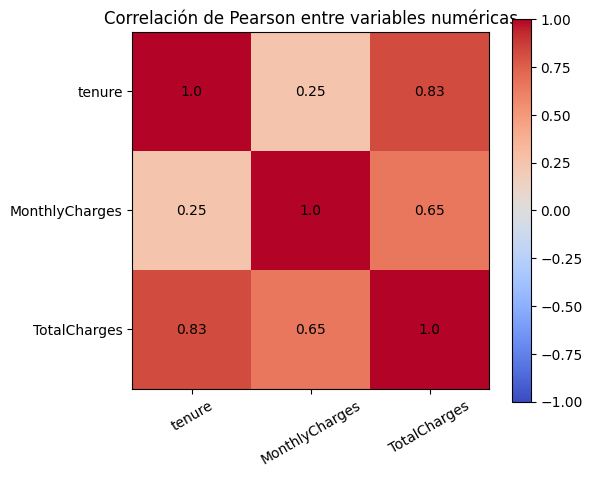

In [51]:
# Mapa de calor de la matriz de correlación

figura, eje = plt.subplots(figsize=(6, 5))
imagen = eje.imshow(matriz_correlacion, cmap="coolwarm", vmin=-1, vmax=1)

eje.set_xticks(range(len(variables_numericas)))
eje.set_xticklabels(variables_numericas, rotation=30)
eje.set_yticks(range(len(variables_numericas)))
eje.set_yticklabels(variables_numericas)

for fila in range(len(variables_numericas)):
    for columna in range(len(variables_numericas)):
        valor = round(matriz_correlacion.iloc[fila, columna], 2)
        eje.text(columna, fila, valor, ha="center", va="center")

figura.colorbar(imagen)
eje.set_title("Correlación de Pearson entre variables numéricas")
plt.tight_layout()
plt.show()

Se observan las siguientes correlaciones:

- **tenure y TotalCharges:** 0,826, correlación positiva fuerte.
- **MonthlyCharges y TotalCharges:** 0,651, correlación positiva
  moderada-fuerte.
- **tenure y MonthlyCharges:** 0,248, correlación débil.

Estos resultados son coherentes con el significado de las variables:
`TotalCharges` representa el total pagado por el cliente, que depende
aproximadamente del tiempo como cliente (`tenure`) y del cargo mensual
(`MonthlyCharges`). En cambio, la antigüedad del cliente y su cargo mensual
son prácticamente independientes entre sí.

La correlación entre `tenure` y `TotalCharges` indica que ambas variables
comparten información, pero no son idénticas, ya que el cargo mensual de un
cliente puede variar a lo largo del tiempo. La alta correlación por sí sola
no justifica eliminar una de ellas; la decisión se analiza en la sección 4
según el modelo utilizado.

### 3.9 Síntesis del análisis exploratorio

- El dataset tiene 7043 clientes y 21 variables, sin registros duplicados.
- `TotalCharges` presentaba 11 valores faltantes ocultos como texto vacío,
  correspondientes a clientes nuevos (`tenure = 0`).
- La variable objetivo está desbalanceada: 26,54 % de los clientes
  abandonaron el servicio.
- Los factores más asociados al abandono son: contrato mensual, pago con
  cheque electrónico, servicio de fibra óptica, ausencia de servicios de
  soporte y poca antigüedad como cliente.
- Existen redundancias entre variables: la categoría "No internet service"
  repite información de `InternetService`, y `TotalCharges` está fuertemente
  correlacionada con `tenure`.
- Este análisis examina cada variable de forma individual; no permite
  separar el efecto de variables que están relacionadas entre sí, lo cual
  corresponde al modelo predictivo.

## 4. Preparación de datos

### 4.1 Selección de variables

Se definen las variables predictoras y la variable objetivo con base en el
significado de cada variable:

- **`customerID` se excluye:** es un identificador único que no describe
  ninguna característica del cliente. Si el modelo lo utilizara, podría
  memorizar clientes específicos en lugar de aprender patrones generalizables.
- **`Churn` es la variable objetivo:** se separa de las predictoras y se
  codifica como 1 (abandonó) y 0 (permaneció). La clase 1 es la clase
  positiva, es decir, la que se busca identificar.
- **Se conservan las 19 variables restantes.** No se eliminan variables por
  su relación con `Churn` observada en el análisis exploratorio, ya que ese
  análisis incluyó el conjunto completo de datos.
- **`TotalCharges` se conserva** a pesar de su correlación de 0,826 con
  `tenure`: la correlación no es perfecta, porque el cargo mensual de un
  cliente puede variar en el tiempo, y el modelo utilizado incluye
  regularización, que reduce los efectos de variables correlacionadas.
- **Las categorías "No internet service" y "No phone service" se mantienen**
  sin modificar: no son valores faltantes y no alteran los datos originales.

**Revisión de información posterior al abandono:** todas las variables
predictoras describen características del cliente, su contrato o sus
servicios, y estarían disponibles antes de que el cliente abandone. Como
limitación, el dataset corresponde a un único momento en el tiempo: para los
clientes que abandonaron, `tenure` y `TotalCharges` reflejan su situación al
momento de su salida.

In [52]:
# 4.1 Definición de variables predictoras y variable objetivo

columnas_excluidas = ["customerID", "Churn"]

# Variables predictoras: todas excepto el identificador y la variable objetivo
predictoras = datos_clientes.drop(columns=columnas_excluidas)

# Variable objetivo: Yes = 1 (abandonó), No = 0 (permaneció)
objetivo = datos_clientes["Churn"].map({"No": 0, "Yes": 1})

print("Dimensiones de las variables predictoras:", predictoras.shape)
print("Dimensiones de la variable objetivo:", objetivo.shape)
print()
print("Variables predictoras:")
print(predictoras.columns.tolist())
print()
print("Distribución de la variable objetivo codificada:")
print(objetivo.value_counts())

if objetivo.isnull().sum() == 0:
    print("La variable objetivo se codificó correctamente (sin valores faltantes).")
else:
    print("Hay valores de Churn que no se pudieron codificar: revisar.")

Dimensiones de las variables predictoras: (7043, 19)
Dimensiones de la variable objetivo: (7043,)

Variables predictoras:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Distribución de la variable objetivo codificada:
Churn
0    5174
1    1869
Name: count, dtype: int64
La variable objetivo se codificó correctamente (sin valores faltantes).


Se obtienen 19 variables predictoras para los 7043 registros. La variable
objetivo codificada conserva la distribución original: 5174 clientes con
valor 0 (permanecieron) y 1869 con valor 1 (abandonaron), sin valores
faltantes, lo que confirma que la codificación no alteró ningún registro.

### 4.2 Tratamiento de valores faltantes

Los 11 valores faltantes de `TotalCharges` corresponden a clientes con
`tenure = 0`, es decir, clientes nuevos a los que aún no se les ha realizado
ningún cobro (sección 3.3). Se evaluaron tres alternativas:

- **Eliminar los registros:** representan solo el 0,16 % del dataset, pero en
  un escenario real también llegarán clientes nuevos con este valor vacío,
  y el modelo debe ser capaz de procesarlos.
- **Imputar con la mediana:** asignaría a clientes sin cobros un cargo total
  que no corresponde a su situación real.
- **Imputar con 0:** coincide con el significado de la variable, ya que un
  cliente que acaba de ingresar no ha pagado nada todavía.

Se elige **imputar con 0**. La imputación se realiza dentro del Pipeline de
preprocesamiento, de modo que se aplique de forma automática tanto al
conjunto de prueba como a los clientes nuevos al momento de realizar
predicciones. Al ser un valor constante, esta imputación no utiliza
información de los datos, por lo que no genera fuga de información.

### 4.3 División en entrenamiento y prueba

Los datos se dividen en 80 % para entrenamiento y 20 % para prueba. El
conjunto de prueba no interviene en ninguna etapa del entrenamiento y se
utiliza únicamente para evaluar el modelo, simulando clientes nuevos.

Se utiliza `stratify` para que ambos conjuntos conserven la misma proporción
de clientes que abandonan, lo cual es importante dado el desbalance de clases,
y `random_state` para que la división sea reproducible.

In [53]:
# 4.3 División en entrenamiento y prueba

(predictoras_entrenamiento,
 predictoras_prueba,
 objetivo_entrenamiento,
 objetivo_prueba) = train_test_split(
    predictoras,
    objetivo,
    test_size=0.2,
    stratify=objetivo,
    random_state=RANDOM_STATE
)

print("Registros de entrenamiento:", len(predictoras_entrenamiento))
print("Registros de prueba:", len(predictoras_prueba))
print()

porcentaje_abandono_total = objetivo.mean() * 100
porcentaje_abandono_entrenamiento = objetivo_entrenamiento.mean() * 100
porcentaje_abandono_prueba = objetivo_prueba.mean() * 100

print("Porcentaje de abandono en el dataset completo:", round(porcentaje_abandono_total, 2), "%")
print("Porcentaje de abandono en entrenamiento:", round(porcentaje_abandono_entrenamiento, 2), "%")
print("Porcentaje de abandono en prueba:", round(porcentaje_abandono_prueba, 2), "%")
print()

faltantes_entrenamiento = predictoras_entrenamiento["TotalCharges"].isnull().sum()
faltantes_prueba = predictoras_prueba["TotalCharges"].isnull().sum()
print("Faltantes de TotalCharges en entrenamiento:", faltantes_entrenamiento)
print("Faltantes de TotalCharges en prueba:", faltantes_prueba)

Registros de entrenamiento: 5634
Registros de prueba: 1409

Porcentaje de abandono en el dataset completo: 26.54 %
Porcentaje de abandono en entrenamiento: 26.54 %
Porcentaje de abandono en prueba: 26.54 %

Faltantes de TotalCharges en entrenamiento: 8
Faltantes de TotalCharges en prueba: 3


El conjunto de entrenamiento quedó con 5634 registros (80 %) y el de prueba
con 1409 registros (20 %). Gracias a la estratificación, la proporción de
clientes que abandonan es de 26,54 % tanto en el dataset completo como en
ambos conjuntos, por lo que el conjunto de prueba representa fielmente la
distribución real de la variable objetivo.

Los 11 valores faltantes de `TotalCharges` quedaron distribuidos en 8
registros de entrenamiento y 3 de prueba. Esto confirma la necesidad de que
la imputación forme parte del preprocesamiento aplicado a ambos conjuntos.

### 4.4 Codificación y transformaciones

Las variables predictoras se agrupan según la transformación que requieren:

- **Numéricas (`tenure`, `MonthlyCharges`):** imputación con la mediana como
  protección ante posibles valores faltantes en datos futuros, y
  escalamiento con `StandardScaler`, ya que las variables tienen escalas muy
  diferentes y modelos como la regresión logística son sensibles a ello.
- **`TotalCharges`:** imputación con 0 (sección 4.2) y escalamiento.
- **Categóricas (16 variables, incluida `SeniorCitizen`):** codificación
  One-Hot, que convierte cada categoría en una columna binaria sin imponer un
  orden artificial entre categorías. `SeniorCitizen` se trata como categórica
  porque, aunque está codificada como 0/1, representa una condición (sí/no) y
  no una cantidad.

In [54]:
# 4.4 Clasificación de columnas por tipo de transformación

# Numéricas: imputación con la mediana (por robustez) y escalamiento
columnas_numericas = ["tenure", "MonthlyCharges"]

# TotalCharges: imputación con 0 (clientes nuevos sin cobros) y escalamiento
columna_cargos_totales = ["TotalCharges"]

# Categóricas (incluye SeniorCitizen): codificación One-Hot
columnas_categoricas = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

# Verificación: todas las predictoras deben estar asignadas exactamente una vez
columnas_asignadas = columnas_numericas + columna_cargos_totales + columnas_categoricas
columnas_predictoras = predictoras.columns.tolist()

print("Columnas asignadas:", len(columnas_asignadas))
print("Columnas predictoras:", len(columnas_predictoras))

if sorted(columnas_asignadas) == sorted(columnas_predictoras):
    print("Todas las variables predictoras están asignadas a una transformación, sin repetir.")
else:
    print("Hay columnas sin asignar o repetidas: revisar las listas.")

Columnas asignadas: 19
Columnas predictoras: 19
Todas las variables predictoras están asignadas a una transformación, sin repetir.


### 4.5 Construcción del preprocesador

Las transformaciones se organizan con `Pipeline` y `ColumnTransformer`.
`Pipeline` encadena pasos en orden (por ejemplo, imputar y luego escalar), y
`ColumnTransformer` aplica a cada grupo de columnas su transformación
correspondiente. En la codificación One-Hot se utiliza
`handle_unknown="ignore"` para que categorías no vistas en entrenamiento no
generen errores, y `drop="if_binary"` para representar las variables de dos
categorías con una sola columna.

In [55]:
# 4.5 Construcción del preprocesador

transformador_numerico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalamiento", StandardScaler())
])

transformador_cargos_totales = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="constant", fill_value=0)),
    ("escalamiento", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("codificacion", OneHotEncoder(handle_unknown="ignore",
                                   drop="if_binary",
                                   sparse_output=False))
])

preprocesador = ColumnTransformer(transformers=[
    ("numericas", transformador_numerico, columnas_numericas),
    ("cargos_totales", transformador_cargos_totales, columna_cargos_totales),
    ("categoricas", transformador_categorico, columnas_categoricas)
])

preprocesador

ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputacion',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalamiento',
                                                  StandardScaler())]),
                                 ['tenure', 'MonthlyCharges']),
                                ('cargos_totales',
                                 Pipeline(steps=[('imputacion',
                                                  SimpleImputer(fill_value=0,
                                                                strategy='constant')),
                                                 ('escalamiento',
                                                  StandardScaler())]),
                                 ['TotalCharges']),
                                ('categoricas',
                                 Pipeline(steps=[('codificacion',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

Las 19 variables predictoras quedaron asignadas a una transformación, sin
columnas omitidas ni repetidas. Esta verificación es necesaria porque
`ColumnTransformer` descarta por defecto, sin generar error, las columnas
que no se asignan a ningún transformador.

El diagrama muestra la estructura del preprocesador: tres transformadores
aplicados en paralelo a sus respectivos grupos de columnas. El estado
"Not fitted" indica que en este punto el preprocesador solo está definido y
todavía no ha aprendido ninguna información de los datos.

### 4.6 Verificación del preprocesador y prevención de fuga de información

El preprocesador se ajusta (`fit`) únicamente con los datos de
entrenamiento: allí aprende las medianas, las medias y desviaciones para el
escalamiento, y las categorías de cada variable. Luego se aplica
(`transform`) a ambos conjuntos con lo aprendido en entrenamiento. De esta
forma, ninguna información del conjunto de prueba interviene en el
preprocesamiento.

In [56]:
# 4.6 Verificación del preprocesador (ajustado solo con entrenamiento)

# fit SOLO con entrenamiento; transform en ambos conjuntos
preprocesador.fit(predictoras_entrenamiento)

entrenamiento_transformado = preprocesador.transform(predictoras_entrenamiento)
prueba_transformada = preprocesador.transform(predictoras_prueba)

print("Dimensiones de entrenamiento transformado:", entrenamiento_transformado.shape)
print("Dimensiones de prueba transformada:", prueba_transformada.shape)
print()

nombres_columnas_transformadas = preprocesador.get_feature_names_out()
print("Columnas generadas por el preprocesador:")
print(list(nombres_columnas_transformadas))
print()

print("Valores faltantes después de transformar (entrenamiento):", np.isnan(entrenamiento_transformado).sum())
print("Valores faltantes después de transformar (prueba):", np.isnan(prueba_transformada).sum())
print()

# Las 3 primeras columnas son las numéricas escaladas
medias_entrenamiento = entrenamiento_transformado[:, 0:3].mean(axis=0)
medias_prueba = prueba_transformada[:, 0:3].mean(axis=0)
print("Media de las columnas numéricas escaladas en entrenamiento:", medias_entrenamiento.round(4))
print("Media de las columnas numéricas escaladas en prueba:", medias_prueba.round(4))

Dimensiones de entrenamiento transformado: (5634, 40)
Dimensiones de prueba transformada: (1409, 40)

Columnas generadas por el preprocesador:
['numericas__tenure', 'numericas__MonthlyCharges', 'cargos_totales__TotalCharges', 'categoricas__gender_Male', 'categoricas__SeniorCitizen_1', 'categoricas__Partner_Yes', 'categoricas__Dependents_Yes', 'categoricas__PhoneService_Yes', 'categoricas__MultipleLines_No', 'categoricas__MultipleLines_No phone service', 'categoricas__MultipleLines_Yes', 'categoricas__InternetService_DSL', 'categoricas__InternetService_Fiber optic', 'categoricas__InternetService_No', 'categoricas__OnlineSecurity_No', 'categoricas__OnlineSecurity_No internet service', 'categoricas__OnlineSecurity_Yes', 'categoricas__OnlineBackup_No', 'categoricas__OnlineBackup_No internet service', 'categoricas__OnlineBackup_Yes', 'categoricas__DeviceProtection_No', 'categoricas__DeviceProtection_No internet service', 'categoricas__DeviceProtection_Yes', 'categoricas__TechSupport_No', 'c

Resultados de la verificación:

- Ambos conjuntos transformados tienen 40 columnas, lo que coincide con el
  número esperado: 3 variables numéricas, 6 variables categóricas binarias
  representadas con una columna cada una, 9 variables de 3 categorías
  (27 columnas) y `PaymentMethod` con 4 categorías (4 columnas).
- Las variables binarias quedaron representadas con una sola columna (por
  ejemplo, `Partner_Yes`: 1 si el cliente tiene pareja, 0 si no).
- No quedan valores faltantes en ninguno de los dos conjuntos: los 11
  valores de `TotalCharges` fueron imputados con 0.
- Las medias de las variables numéricas escaladas son 0 en entrenamiento y
  cercanas a 0, pero no iguales, en prueba (−0,0232, −0,0279 y −0,043).
  Esto demuestra que el escalamiento del conjunto de prueba se realizó con
  la media y la desviación estándar aprendidas del conjunto de
  entrenamiento, sin utilizar información del conjunto de prueba.

En la sección 6, este preprocesador se integra con el modelo en un único
Pipeline, que se ajusta nuevamente solo con los datos de entrenamiento.

**Resumen de medidas para evitar la fuga de información:**

1. `Churn` se separó de las variables predictoras y no se utiliza como
   predictor.
2. `customerID` se excluyó por ser un identificador.
3. Las variables no se seleccionaron según su relación con `Churn` en el
   dataset completo.
4. Los datos se dividieron antes de cualquier transformación que aprenda de
   los datos.
5. La imputación, el escalamiento y la codificación se ajustan únicamente
   con el conjunto de entrenamiento, mediante `Pipeline` y
   `ColumnTransformer`.
6. Al conjunto de prueba solo se le aplican las transformaciones aprendidas
   en entrenamiento.
7. Ninguna variable predictora contiene información que solo estaría
   disponible después del abandono del cliente.

## 5. Modelo base

### 5.1 Selección de métricas

El problema presenta clases desbalanceadas (26,54 % de abandono), por lo que
el accuracy puede ser engañoso: un modelo que prediga que ningún cliente
abandona obtendría un accuracy cercano al 73 % sin aprender ningún patrón.

En el contexto de abandono de clientes, los errores no tienen el mismo costo:

- **Falso negativo:** el modelo predice que el cliente permanece, pero
  abandona. La empresa pierde al cliente sin haber podido actuar. Es el
  error más costoso.
- **Falso positivo:** el modelo predice que el cliente abandona, pero
  permanece. La empresa invierte en una acción de retención innecesaria.

Por esta razón se definen las siguientes métricas:

- **Métrica principal: F1-score de la clase "abandona".** Combina la
  capacidad de detectar a los clientes que abandonan (recall) con la
  confiabilidad de esas alertas (precision), y penaliza a los modelos que
  sacrifican una de las dos.
- **Métricas complementarias:** recall y precision por separado, para
  entender el tipo de errores del modelo, y ROC-AUC, que mide la capacidad
  del modelo para ordenar a los clientes según su riesgo de abandono,
  independientemente del umbral de decisión.
- **Accuracy:** se reporta como referencia, pero no se utiliza para decidir
  debido al desbalance de clases.

### 5.2 Función de evaluación

Se define una función que calcula todas las métricas a partir de un modelo
entrenado y un conjunto de datos. Utilizar la misma función para el modelo
base y para el modelo predictivo garantiza que ambos se evalúan exactamente
de la misma manera.

In [57]:
# 5.2 Función de evaluación

def evaluar_modelo(nombre_modelo, modelo_entrenado, predictoras_evaluacion, objetivo_real):
    """
    Calcula las métricas de evaluación de un modelo de clasificación binaria.
    Devuelve un diccionario con el nombre del modelo y sus métricas.
    """
    predicciones = modelo_entrenado.predict(predictoras_evaluacion)
    probabilidades_abandono = modelo_entrenado.predict_proba(predictoras_evaluacion)[:, 1]

    resultados = {
        "modelo": nombre_modelo,
        "accuracy": accuracy_score(objetivo_real, predicciones),
        "precision": precision_score(objetivo_real, predicciones, zero_division=0),
        "recall": recall_score(objetivo_real, predicciones, zero_division=0),
        "f1": f1_score(objetivo_real, predicciones, zero_division=0),
        "roc_auc": roc_auc_score(objetivo_real, probabilidades_abandono)
    }

    return resultados

### 5.3 Construcción y entrenamiento del modelo base

El modelo base es un `DummyClassifier` con la estrategia `most_frequent`, que
ignora las variables predictoras y predice para todos los clientes la clase
más frecuente del conjunto de entrenamiento. Representa el desempeño que se
obtendría sin aprender ningún patrón de los datos, y es la referencia mínima
que el modelo predictivo debe superar.

El modelo base se integra en un Pipeline con el mismo preprocesador de la
sección 4, para que siga exactamente el mismo flujo de entrenamiento y
evaluación que el modelo predictivo. Se entrena únicamente con el conjunto
de entrenamiento.

In [58]:
# 5.3 Construcción y entrenamiento del modelo base

modelo_base = Pipeline(steps=[
    ("preprocesamiento", preprocesador),
    ("clasificador", DummyClassifier(strategy="most_frequent"))
])

# Entrenamiento SOLO con el conjunto de entrenamiento
modelo_base.fit(predictoras_entrenamiento, objetivo_entrenamiento)

print("Clase que predice el modelo base para todos los clientes:",
      modelo_base.named_steps["clasificador"].classes_[
          modelo_base.named_steps["clasificador"].class_prior_.argmax()
      ])

modelo_base

Clase que predice el modelo base para todos los clientes: 0


Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalamiento',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges']),
                                                 ('cargos_totales',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('escalamiento',
                                                                   StandardScaler())]),
                                                  ['Total...
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('clasificador', DummyClassifier(strategy='most_frequent'))])

El modelo base aprendió a predecir la clase 0 (permanece) para todos los
clientes, ya que es la clase más frecuente en el conjunto de entrenamiento.
El diagrama muestra el Pipeline completo en estado ajustado: el
preprocesador seguido del `DummyClassifier`.

### 5.4 Evaluación del modelo base

El modelo base se evalúa en el conjunto de prueba, que no fue utilizado en
el entrenamiento.

In [59]:
# 5.4 Evaluación del modelo base

# Métricas en el conjunto de prueba
resultados_modelo_base = evaluar_modelo(
    "Modelo base (DummyClassifier)",
    modelo_base,
    predictoras_prueba,
    objetivo_prueba
)

print("Métricas del modelo base en el conjunto de prueba:")
for nombre_metrica in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(" ", nombre_metrica, ":", round(resultados_modelo_base[nombre_metrica], 4))
print()

# Matriz de confusión
predicciones_modelo_base = modelo_base.predict(predictoras_prueba)
matriz_confusion_base = confusion_matrix(objetivo_prueba, predicciones_modelo_base)

tabla_matriz_confusion_base = pd.DataFrame(
    matriz_confusion_base,
    index=["Real: permanece (0)", "Real: abandona (1)"],
    columns=["Predicho: permanece (0)", "Predicho: abandona (1)"]
)
print("Matriz de confusión del modelo base:")
print(tabla_matriz_confusion_base)
print()

# Reporte de clasificación
print("Reporte de clasificación del modelo base:")
print(classification_report(
    objetivo_prueba,
    predicciones_modelo_base,
    target_names=["Permanece (0)", "Abandona (1)"],
    zero_division=0
))

Métricas del modelo base en el conjunto de prueba:
  accuracy : 0.7346
  precision : 0.0
  recall : 0.0
  f1 : 0.0
  roc_auc : 0.5

Matriz de confusión del modelo base:
                     Predicho: permanece (0)  Predicho: abandona (1)
Real: permanece (0)                     1035                       0
Real: abandona (1)                       374                       0

Reporte de clasificación del modelo base:
               precision    recall  f1-score   support

Permanece (0)       0.73      1.00      0.85      1035
 Abandona (1)       0.00      0.00      0.00       374

     accuracy                           0.73      1409
    macro avg       0.37      0.50      0.42      1409
 weighted avg       0.54      0.73      0.62      1409



Resultados del modelo base en el conjunto de prueba (1409 clientes):

| Métrica   | Valor  |
|-----------|--------|
| Accuracy  | 0,7346 |
| Precision | 0,0    |
| Recall    | 0,0    |
| F1-score  | 0,0    |
| ROC-AUC   | 0,5    |

La matriz de confusión muestra que el modelo clasificó correctamente a los
1035 clientes que permanecieron, pero no detectó a ninguno de los 374
clientes que abandonaron: todos corresponden a falsos negativos.

Interpretación:

- El accuracy de 73,46 % coincide exactamente con la proporción de clientes
  que permanecen en el conjunto de prueba (1035 / 1409). El modelo no
  aprendió ningún patrón; su accuracy proviene únicamente del desbalance
  de clases.
- Precision, recall y F1 de la clase "abandona" son 0, ya que el modelo
  nunca predice abandono.
- El ROC-AUC de 0,5 indica que el modelo no tiene capacidad para distinguir
  entre clientes que abandonan y clientes que permanecen, lo cual equivale
  a una clasificación al azar.
- Aunque el reporte muestra un F1 de 0,85 para la clase "permanece" y un F1
  promedio ponderado de 0,62, estos valores se deben a la clase mayoritaria
  y no reflejan la capacidad de detectar el abandono, que es el objetivo
  del problema.

Estos resultados confirman que el accuracy no es una métrica adecuada para
este problema y establecen la referencia mínima que el modelo predictivo
debe superar: un modelo útil debe lograr detectar una proporción
significativa de los clientes que abandonan (recall), con alertas
confiables (precision), y un ROC-AUC claramente superior a 0,5.

## 6. Modelo predictivo

### 6.1 Justificación del algoritmo

Se consideraron tres alternativas para clasificación binaria:

| Algoritmo | Ventajas | Desventajas |
|---|---|---|
| Regresión logística | Interpretable mediante sus coeficientes; genera probabilidades; eficiente; adecuada para variables codificadas con One-Hot | Solo capta relaciones lineales; requiere escalamiento |
| Árbol de decisión | Fácil de explicar como reglas; capta relaciones no lineales | Tiende a sobreajustarse; es inestable ante pequeños cambios en los datos |
| Random Forest | Alto desempeño; robusto al sobreajuste; capta relaciones complejas | Difícil de interpretar; mayor costo computacional; más hiperparámetros |

Se selecciona la **regresión logística** por las siguientes razones:

- Es un modelo estándar para clasificación binaria, adecuado para el
  tamaño y el tipo de variables del dataset.
- El análisis exploratorio mostró relaciones claras y en una misma dirección
  entre varias variables y el abandono (por ejemplo, a mayor duración del
  contrato y mayor antigüedad, menor abandono), que un modelo lineal puede
  capturar adecuadamente.
- Sus coeficientes permiten interpretar qué variables aumentan o disminuyen
  el riesgo de abandono, lo cual es útil para la toma de decisiones de la
  empresa.
- Incluye regularización L2 por defecto, lo que reduce el sobreajuste y los
  efectos de variables correlacionadas, como `tenure` y `TotalCharges`.
- El preprocesamiento definido en la sección 4 (escalamiento y codificación
  One-Hot) es el adecuado para este modelo.

Se prioriza un modelo interpretable y técnicamente justificado sobre uno más
complejo. Modelos como Random Forest se consideran una posible mejora en
fases posteriores.

### 6.2 Manejo del desbalance de clases

Debido al desbalance de clases (26,54 % de abandono), se evalúan dos
configuraciones de la regresión logística:

- **Sin balanceo:** todos los clientes tienen el mismo peso durante el
  entrenamiento.
- **Balanceado (`class_weight="balanced"`):** los errores en la clase
  minoritaria (abandono) tienen mayor peso, en proporción inversa a la
  frecuencia de cada clase.

La elección se realiza mediante **validación cruzada estratificada de 5
particiones, utilizando únicamente el conjunto de entrenamiento**. El
conjunto de prueba no interviene en esta decisión, para evitar que influya
en el diseño del modelo. Como el preprocesador forma parte del Pipeline, en
cada partición se ajusta solo con los datos de entrenamiento de esa
partición, lo que evita la fuga de información dentro de la validación
cruzada. Se elige la configuración con mayor F1 promedio, que es la métrica
principal definida en la sección 5.1.

In [63]:
# 6.2 Selección del manejo del desbalance con validación cruzada
#     (solo con el conjunto de entrenamiento)

validacion_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

configuraciones_class_weight = {
    "Sin balanceo": None,
    "Balanceado": "balanced"
}

metricas_validacion = ["f1", "recall", "precision", "roc_auc"]

filas_resultados_validacion = []
promedio_f1_por_configuracion = {}

for nombre_configuracion, valor_class_weight in configuraciones_class_weight.items():
    pipeline_candidato = Pipeline(steps=[
        ("preprocesamiento", preprocesador),
        ("clasificador", LogisticRegression(max_iter=1000,
                                            class_weight=valor_class_weight,
                                            random_state=RANDOM_STATE))
    ])

    resultados_validacion = cross_validate(
        pipeline_candidato,
        predictoras_entrenamiento,
        objetivo_entrenamiento,
        cv=validacion_cruzada,
        scoring=metricas_validacion
    )

    fila = {"configuración": nombre_configuracion}
    for nombre_metrica in metricas_validacion:
        valores_folds = resultados_validacion["test_" + nombre_metrica]
        fila[nombre_metrica + " (promedio)"] = round(valores_folds.mean(), 4)
        fila[nombre_metrica + " (desv. est.)"] = round(valores_folds.std(), 4)

    filas_resultados_validacion.append(fila)
    promedio_f1_por_configuracion[nombre_configuracion] = resultados_validacion["test_f1"].mean()

tabla_validacion_cruzada = pd.DataFrame(filas_resultados_validacion)
tabla_validacion_cruzada

,configuración,f1 (promedio),f1 (desv. est.),recall (promedio),recall (desv. est.),precision (promedio),precision (desv. est.),roc_auc (promedio),roc_auc (desv. est.)
0,Sin balanceo,0.5932,0.0299,0.5445,0.0407,0.6530,0.0267,0.8462,0.0126
1,Balanceado,0.6293,0.0223,0.8027,0.0360,0.5178,0.0186,0.8460,0.0124


Resultados de la validación cruzada (promedio ± desviación estándar en 5
particiones del conjunto de entrenamiento):

| Métrica   | Sin balanceo      | Balanceado        |
|-----------|-------------------|-------------------|
| F1        | 0,5932 ± 0,0299   | 0,6293 ± 0,0223   |
| Recall    | 0,5445 ± 0,0407   | 0,8027 ± 0,0360   |
| Precision | 0,6530 ± 0,0267   | 0,5178 ± 0,0186   |
| ROC-AUC   | 0,8462 ± 0,0126   | 0,8460 ± 0,0124   |

Interpretación:

- **El balanceo aumenta considerablemente el recall** (de 54,45 % a
  80,27 %): el modelo pasa de detectar aproximadamente 54 de cada 100
  clientes que abandonan a detectar aproximadamente 80.
- **A cambio, la precision disminuye** (de 65,30 % a 51,78 %): con el
  balanceo, aproximadamente la mitad de los clientes señalados como
  posibles abandonos realmente abandonan, lo que implica más acciones de
  retención innecesarias.
- **El F1 aumenta de 0,5932 a 0,6293**, ya que el aumento en recall compensa
  la disminución en precision. La mejora es moderada, del mismo orden que
  la variabilidad entre particiones.
- **El ROC-AUC es prácticamente igual** en ambas configuraciones (0,8462 y
  0,8460). Esto indica que el balanceo no modifica la capacidad del modelo
  para ordenar a los clientes según su riesgo, sino el criterio con el que
  se clasifica a un cliente como posible abandono.
- **Las desviaciones estándar son bajas** (entre 0,0124 y 0,0407), lo que
  indica que los resultados son estables entre particiones.

Se selecciona la configuración **balanceada** porque obtiene el mayor F1
promedio, que es la métrica principal, y porque prioriza la detección de los
clientes que abandonan, que es el error más costoso para la empresa según lo
definido en la sección 5.1.

### 6.3 Construcción del modelo predictivo

El modelo predictivo se construye como un Pipeline que integra el
preprocesador de la sección 4 con la regresión logística. La configuración
de `class_weight` se selecciona automáticamente a partir de los resultados
de la validación cruzada, para que el notebook sea reproducible sin
intervención manual. Se utiliza `max_iter=1000` para asegurar la
convergencia del algoritmo y `random_state` para la reproducibilidad.

In [61]:
# 6.3 Construcción del modelo predictivo

# Se elige la configuración con mayor F1 promedio en validación cruzada
f1_sin_balanceo = promedio_f1_por_configuracion["Sin balanceo"]
f1_balanceado = promedio_f1_por_configuracion["Balanceado"]

if f1_balanceado > f1_sin_balanceo:
    class_weight_elegido = "balanced"
    nombre_configuracion_elegida = "Balanceado"
else:
    class_weight_elegido = None
    nombre_configuracion_elegida = "Sin balanceo"

print("F1 promedio sin balanceo:", round(f1_sin_balanceo, 4))
print("F1 promedio balanceado:", round(f1_balanceado, 4))
print("Configuración elegida:", nombre_configuracion_elegida)

modelo_predictivo = Pipeline(steps=[
    ("preprocesamiento", preprocesador),
    ("clasificador", LogisticRegression(max_iter=1000,
                                        class_weight=class_weight_elegido,
                                        random_state=RANDOM_STATE))
])

F1 promedio sin balanceo: 0.5932
F1 promedio balanceado: 0.6293
Configuración elegida: Balanceado


Con base en la validación cruzada, se seleccionó automáticamente la
configuración balanceada (`class_weight="balanced"`), cuyo F1 promedio
(0,6293) es mayor que el de la configuración sin balanceo (0,5932).

### 6.4 Entrenamiento

El modelo se entrena únicamente con el conjunto de entrenamiento. Dentro del
Pipeline, el preprocesador aprende sus parámetros (medianas, medias,
desviaciones y categorías) a partir de estos datos, y luego la regresión
logística aprende sus coeficientes. El conjunto de prueba se reserva para la
evaluación final en la sección 7.

In [62]:
# 6.4 Entrenamiento del modelo predictivo

# Entrenamiento SOLO con el conjunto de entrenamiento
modelo_predictivo.fit(predictoras_entrenamiento, objetivo_entrenamiento)

clasificador_entrenado = modelo_predictivo.named_steps["clasificador"]

print("Número de variables que recibe el clasificador:", clasificador_entrenado.coef_.shape[1])
print("Iteraciones necesarias para converger:", clasificador_entrenado.n_iter_[0])

if clasificador_entrenado.n_iter_[0] < 1000:
    print("El modelo convergió correctamente (usó menos iteraciones que el máximo).")
else:
    print("El modelo alcanzó el máximo de iteraciones: podría no haber convergido.")

modelo_predictivo

Número de variables que recibe el clasificador: 40
Iteraciones necesarias para converger: 34
El modelo convergió correctamente (usó menos iteraciones que el máximo).


Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('numericas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalamiento',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges']),
                                                 ('cargos_totales',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('escalamiento',
                                                                   StandardScaler())]),
                                                  ['Total...
                                                                                 sparse_output=False))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('clasificador',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

El modelo recibe 40 variables, que coinciden con las columnas generadas por
el preprocesador (sección 4.6). El algoritmo convergió en 34 iteraciones,
muy por debajo del máximo establecido (1000), lo que confirma que el
entrenamiento finalizó correctamente.

El modelo queda entrenado y listo para su evaluación con el conjunto de
prueba, que hasta este punto no ha sido utilizado en ninguna etapa del
entrenamiento ni de la selección de la configuración.